In [19]:
import numpy as np
import cma_utils
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

N_SYMBOLS = 100000
NUM_TAPS=51

In [20]:
def cluster_constellation(complex_points, n_clusters=16):
    """
    Clusters complex signal points into exactly n_clusters regions.
    """
    # Convert to 2D real array: [[real1, imag1], [real2, imag2], ...]
    data = np.array([[z.real, z.imag] for z in complex_points])
    
    # Initialize KMeans to find exactly 16 centers
    # 'n_init' handles multiple restarts to find the best fit
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(data)
    
    # Organize the original complex points into their respective clusters
    clusters = {i: [] for i in range(n_clusters)}
    for label, original_z in zip(labels, complex_points):
        clusters[label].append(original_z)
        
    return clusters


In [21]:
initial_symbols=cma_utils.gen_I_Q_16_qam(N_SYMBOLS)
E_after_pmd = cma_utils.apply_pmd( 
    E_in=initial_symbols, 
    # DGD_ps_per_sqrt_km=31.6, # typical mean DGD 
    DGD_ps_per_sqrt_km=31.6,
    L_m=10000, # fiber length
    N_sections=20, # number of fiber sections 
    Rs=32e9, # 32 gbaud
    SpS=4 # samples per symbol 
    )
symbols_with_pmd_corrected_cma,info_dict_cma = cma_utils.cma_python(E_after_pmd,NUM_TAPS,mu_CMA=1e-4)


tau_Ts 0.7760909753066169


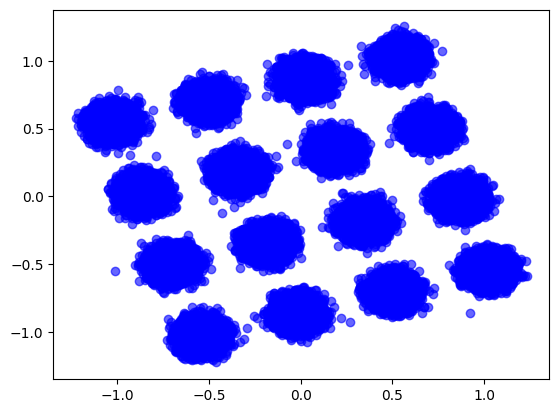

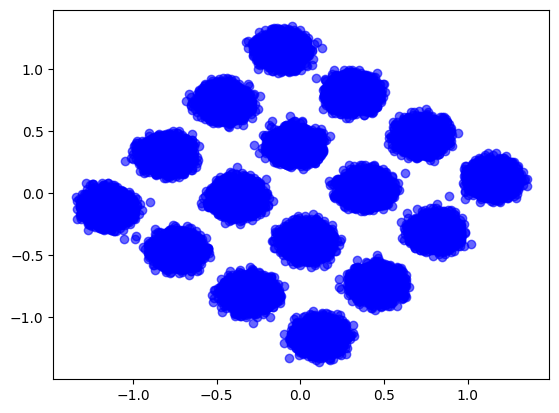

In [22]:
cma_utils.plot_constellation(symbols_with_pmd_corrected_cma)

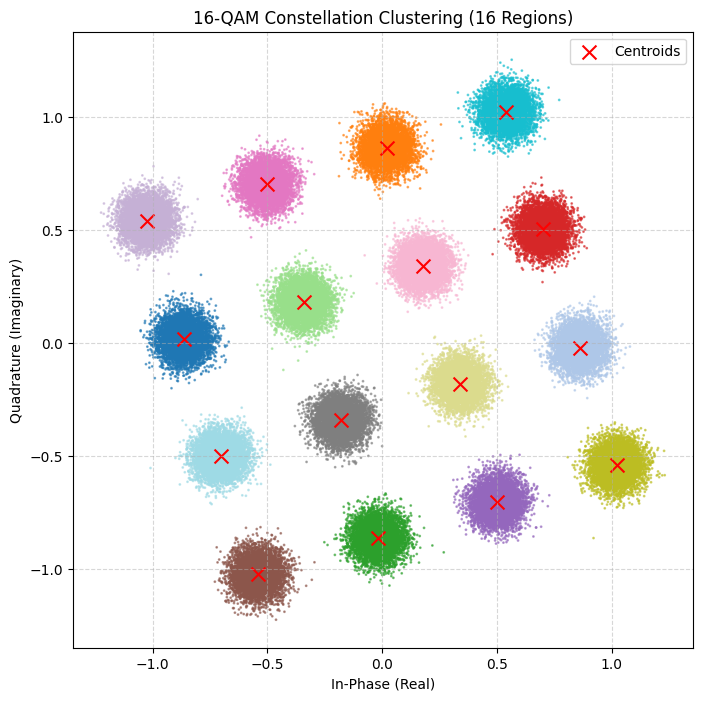

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def cluster_and_plot(complex_points, n_clusters=16):
    # 1. Prepare data
    data = np.array([[z.real, z.imag] for z in complex_points])
    
    # 2. Run KMeans
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(data)
    centers = kmeans.cluster_centers_

    # 3. Plotting
    plt.figure(figsize=(8, 8))
    
    # Scatter plot with colors assigned by cluster label
    # cmap='tab20' gives us enough distinct colors for 16 regions
    scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, s=1, cmap='tab20', alpha=0.6)
    
    # Mark the calculated centers (Centroids)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100, label='Centroids')
    
    plt.title(f'16-QAM Constellation Clustering ({n_clusters} Regions)')
    plt.xlabel('In-Phase (Real)')
    plt.ylabel('Quadrature (Imaginary)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # 4. Return the points grouped by cluster
    clusters = {i: [] for i in range(n_clusters)}
    for label, original_z in zip(labels, complex_points):
        clusters[label].append(original_z)
        
    return clusters

# Example Usage (replace 'your_data' with your list of complex numbers):
clusters = cluster_and_plot(symbols_with_pmd_corrected_cma[:,0], n_clusters=16)

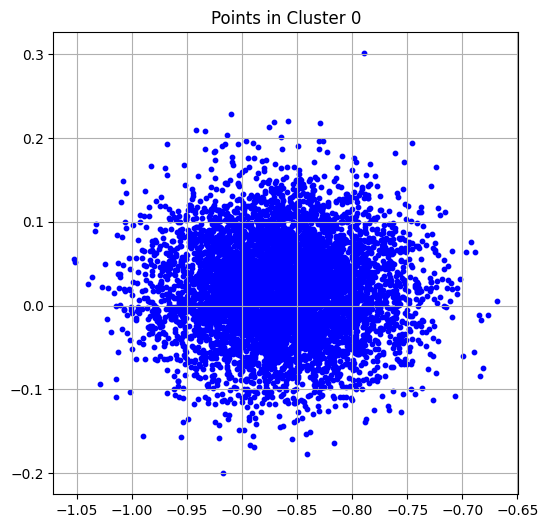

In [30]:
# Assuming 'clusters' is the dictionary returned by the function
cluster_0_points = np.array(clusters[0])

plt.figure(figsize=(6, 6))

# Plot only the points belonging to index 0
plt.scatter(cluster_0_points.real, cluster_0_points.imag, c='blue', s=10)

# Optional: Set axes limits to see where it sits in the whole constellation
plt.title("Points in Cluster 0")
plt.grid(True)
plt.show()

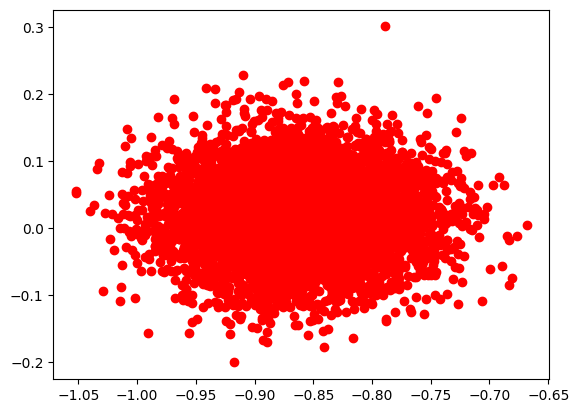